<a href="https://colab.research.google.com/github/MachineLearnia/Python-Machine-Learning/blob/master/17%20-%20Pandas%20(les%20Bases).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 17/30 Pandas (les Bases) Et Analyse du Titanic

In [566]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## 1. Charger vos données dans un DataFrame Pandas

https://www.youtube.com/redirect?q=http%3A%2F%2Fbiostat.mc.vanderbilt.edu%2Fwiki%2Fpub%2FMain%2FDataSets%2Ftitanic3.xls&redir_token=IS7fnKxJQSAQBgyL_W_n-Yg2XZJ8MTU4NzkxOTk0MkAxNTg3ODMzNTQy&v=zZkNOdBWgFQ&event=video_description


Les options les plus courantes :
- read_csv
- read_excel



In [567]:
%pip install xlrd
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [568]:
data = pd.read_excel("dataset/titanic.xls", engine="xlrd")
data_ori = data.copy()


In [569]:
print(data.shape)
print(data.columns)
data.head()


(1309, 14)
Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'], dtype='object')


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [570]:
data.describe()
data_ori = data.copy()


## 2. Nettoyer votre Dataset avec drop(), dropna() et fillna()

In [571]:
data = data.drop(['name', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'], axis=1)


In [572]:
data = data.dropna(axis=0)
data.shape


(1046, 4)

In [573]:
data.tail()


,pclass,survived,sex,age
1301,3,0,male,45.5
1304,3,0,female,14.5
1306,3,0,male,26.5
1307,3,0,male,27.0
1308,3,0,male,29.0


In [574]:
data.describe()


,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


<Axes: >

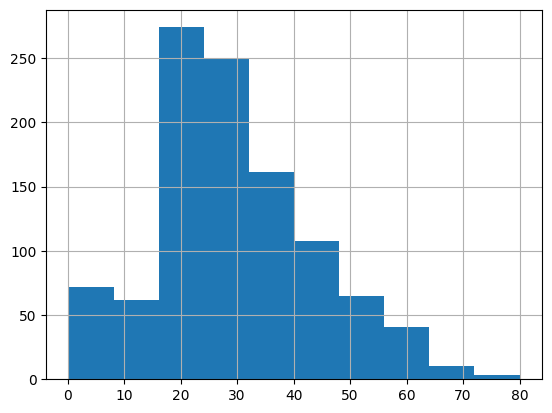

In [575]:
data['age'].hist()


## 3. Groupby() et value_counts()

In [576]:
data.groupby(['sex']).mean()


,pclass,survived,age
sex,,,
female,2.048969,0.752577,28.687071
male,2.300912,0.205167,30.585233


In [577]:
data.groupby(['sex', 'pclass']).mean()


survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

In [578]:
data[data["age"] < 18].groupby(["sex", "pclass"]).mean()


survived        age
sex    pclass                     
female 1       0.875000  14.125000
       2       1.000000   8.273150
       3       0.543478   8.416667
male   1       0.857143   9.845243
       2       0.733333   6.222220
       3       0.233333   9.838888

In [579]:
data["pclass"].value_counts(), data["pclass"].value_counts().sum()


(pclass
 3    501
 1    284
 2    261
 Name: count, dtype: int64,
 np.int64(1046))

<Axes: xlabel='pclass'>

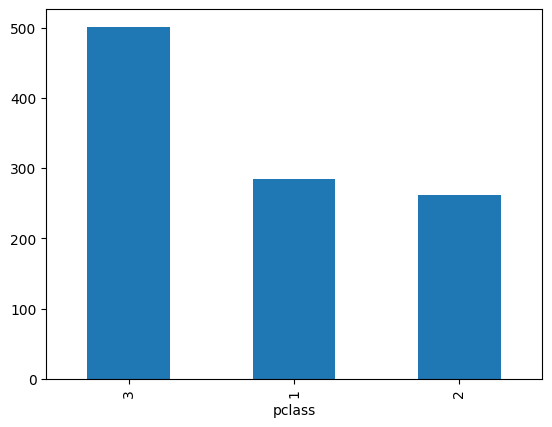

In [580]:
data["pclass"].value_counts().plot.bar()


In [581]:
data[data["age"] < 18]["pclass"].value_counts(), data[data["age"] < 18][
    "pclass"
].value_counts().sum()


(pclass
 3    106
 2     33
 1     15
 Name: count, dtype: int64,
 np.int64(154))

In [582]:
data['age']


0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1301    45.5000
1304    14.5000
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1046, dtype: float64

In [583]:
data_indexedbyname = data_ori.set_index('name')
data_indexedbyname


,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
name,,,,,,,,,,,,,
"Allen, Miss. Elisabeth Walton",1,1,female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
"Allison, Master. Hudson Trevor",1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
"Allison, Miss. Helen Loraine",1,0,female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
"Allison, Mr. Hudson Joshua Creighton",1,0,male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,0,female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zabour, Miss. Hileni",3,0,female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
"Zabour, Miss. Thamine",3,0,female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
"Zakarian, Mr. Mapriededer",3,0,male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN


In [584]:
data


,pclass,survived,sex,age
0,1,1,female,29.0000
1,1,1,male,0.9167
2,1,0,female,2.0000
3,1,0,male,30.0000
4,1,0,female,25.0000
...,...,...,...,...
1301,3,0,male,45.5000
1304,3,0,female,14.5000
1306,3,0,male,26.5000
1307,3,0,male,27.0000


In [585]:
data['sex']


0       female
1         male
2       female
3         male
4       female
         ...  
1301      male
1304    female
1306      male
1307      male
1308      male
Name: sex, Length: 1046, dtype: object

In [586]:
data['age']


0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1301    45.5000
1304    14.5000
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1046, dtype: float64

In [587]:
data["age"][0:4]


0    29.0000
1     0.9167
2     2.0000
3    30.0000
Name: age, dtype: float64

In [588]:
(data['age'] > 70).head() # Mask


0    False
1    False
2    False
3    False
4    False
Name: age, dtype: bool

In [589]:
data[data['age'] > 70]['survived'].value_counts()


survived
0    4
1    2
Name: count, dtype: int64

In [590]:
data


,pclass,survived,sex,age
0,1,1,female,29.0000
1,1,1,male,0.9167
2,1,0,female,2.0000
3,1,0,male,30.0000
4,1,0,female,25.0000
...,...,...,...,...
1301,3,0,male,45.5000
1304,3,0,female,14.5000
1306,3,0,male,26.5000
1307,3,0,male,27.0000


In [591]:
data.shape, f'Le huitième passager a {int(data.iloc[7, 3])} ans' # index localisation


((1046, 4), 'Le huitième passager a 39 ans')

In [592]:
pd.set_option("display.max_columns", None)  # affiche toutes les colonnes
pd.set_option("display.width", 2000)  # évite les retours à la ligne

data_reset = data_indexedbyname.reset_index()
data_reset.iloc[:, :3].shape, data_reset.iloc[:, :7].head()


((1309, 3),
                                               name  pclass  survived     sex      age  sibsp  parch
 0                    Allen, Miss. Elisabeth Walton       1         1  female  29.0000      0      0
 1                   Allison, Master. Hudson Trevor       1         1    male   0.9167      1      2
 2                     Allison, Miss. Helen Loraine       1         0  female   2.0000      1      2
 3             Allison, Mr. Hudson Joshua Creighton       1         0    male  30.0000      1      2
 4  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)       1         0  female  25.0000      1      2)

In [593]:
data_reset.loc[:2, ['name', 'age', 'survived']] # Selection de colonnes


,name,age,survived
0,"Allen, Miss. Elisabeth Walton",29.0000,1
1,"Allison, Master. Hudson Trevor",0.9167,1
2,"Allison, Miss. Helen Loraine",2.0000,0


In [594]:
data.iloc[:2, 0:3]


,pclass,survived,sex
0,1,1,female
1,1,1,male


## 4. Exercice de "Feature Ingeneering"
- Créer des catégories d'ages avec la fonction map() de pandas
- Créer des catégories de genres avec cat.codes

In [595]:
def category_ages(age):
    if age <= 20:
        return '<20 ans'
    elif (age > 20) & (age <= 30):
        return '20-30 ans'
    elif (age > 30) & (age <= 40):
        return '30-40 ans'
    else:
        return '+40 ans'


In [596]:
data['age'] = data['age'].map(category_ages)
data['age']


0       20-30 ans
1         <20 ans
2         <20 ans
3       20-30 ans
4       20-30 ans
          ...    
1301      +40 ans
1304      <20 ans
1306    20-30 ans
1307    20-30 ans
1308    20-30 ans
Name: age, Length: 1046, dtype: object

<Axes: >

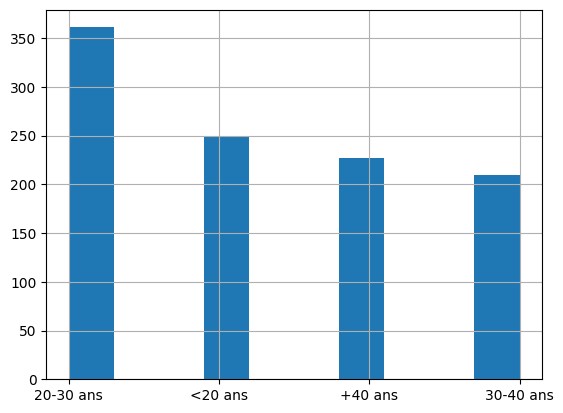

In [597]:
data['age'].hist()


In [598]:
def reset_data():
    return data_ori[["name", "sex"]].copy()

data = reset_data()
data.head(3)


,name,sex
0,"Allen, Miss. Elisabeth Walton",female
1,"Allison, Master. Hudson Trevor",male
2,"Allison, Miss. Helen Loraine",female


In [599]:
data = data.drop(1, axis=0)
data = data.reset_index(drop=True)
data.head(3)


,name,sex
0,"Allen, Miss. Elisabeth Walton",female
1,"Allison, Miss. Helen Loraine",female
2,"Allison, Mr. Hudson Joshua Creighton",male


## Codification du sex

In [600]:
data = reset_data()
data['sex_coded'] = data["sex"].map({'male': 0, 'female': 1})
data.loc[:, ['name', 'sex', 'sex_coded']].head(3)


,name,sex,sex_coded
0,"Allen, Miss. Elisabeth Walton",female,1
1,"Allison, Master. Hudson Trevor",male,0
2,"Allison, Miss. Helen Loraine",female,1


In [601]:
data = reset_data()
pd.set_option("future.no_silent_downcasting", True) # Pas de warning pour le down casting
data["sex_coded1"] = data["sex"].replace({"male": 0, "female": 1}) # str → str 
data["sex_coded2"] = data["sex"].replace({"male": 0, "female": 1}).astype(int) # str → int
data["sex_coded3"] = data["sex"].replace(["male", "female"], [0, 1]).astype(int) # str → int
data.head(3)


,name,sex,sex_coded1,sex_coded2,sex_coded3
0,"Allen, Miss. Elisabeth Walton",female,1,1,1
1,"Allison, Master. Hudson Trevor",male,0,0,0
2,"Allison, Miss. Helen Loraine",female,1,1,1


In [602]:
data = reset_data()
data['sex'].astype('category').cat.codes
# ATTENTION: Code inversé


0       0
1       1
2       0
3       1
4       0
       ..
1304    0
1305    0
1306    1
1307    1
1308    1
Length: 1309, dtype: int8

In [603]:
cat = data["sex"].astype("category")
print(cat.cat.categories)   # les catégories
print(cat.cat.codes)        # les codes



Index(['female', 'male'], dtype='object')
0       0
1       1
2       0
3       1
4       0
       ..
1304    0
1305    0
1306    1
1307    1
1308    1
Length: 1309, dtype: int8


In [ ]:
cat = data["sex"].astype("category")
mapping = dict(enumerate(cat.cat.categories))
print(mapping)


{0: 'female', 1: 'male'}
